In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from scipy.ndimage import uniform_filter


PROJECT = Path(r"Z:\Projects\monsoon-postprocessing")

PREDICTION_FILE = (
    PROJECT
    / "data"
    / "processed"
    / "july2018_baseline_predictions.nc"
)

OUTPUT_FILE = (
    PROJECT
    / "data"
    / "processed"
    / "july2018_extreme_metrics.csv"
)


with xr.open_dataset(PREDICTION_FILE) as ds:
    prediction_ds = ds.load()

print(prediction_ds)

<xarray.Dataset> Size: 2MB
Dimensions:                      (date: 5, latitude: 129, longitude: 121)
Coordinates:
  * date                         (date) datetime64[ns] 40B 2018-07-27 ... 201...
  * latitude                     (latitude) float64 1kB 6.0 6.25 ... 37.75 38.0
  * longitude                    (longitude) float64 968B 68.0 68.25 ... 98.0
Data variables:
    raw_gefs_rainfall            (date, latitude, longitude) float32 312kB na...
    additive_corrected_rainfall  (date, latitude, longitude) float32 312kB na...
    linear_corrected_rainfall    (date, latitude, longitude) float32 312kB na...
    gradient_boosting_rainfall   (date, latitude, longitude) float32 312kB na...
    imerg_rainfall               (date, latitude, longitude) float32 312kB na...
Attributes:
    training_period:        2018-07-01 to 2018-07-26
    testing_period:         2018-07-27 to 2018-07-31
    best_validation_model:  Linear Regression


In [2]:
MODEL_VARIABLES = {
    "Raw GEFS": "raw_gefs_rainfall",
    "Additive": "additive_corrected_rainfall",
    "Linear Regression": "linear_corrected_rainfall",
    "Gradient Boosting": "gradient_boosting_rainfall"
}

THRESHOLDS = {
    "Heavy": 64.5,
    "Very Heavy": 115.6,
    "Extremely Heavy": 204.5
}

observed = prediction_ds["imerg_rainfall"]

In [3]:
def categorical_metrics(
    forecast,
    observed,
    threshold
):
    forecast_values = np.asarray(
        forecast
    ).ravel()

    observed_values = np.asarray(
        observed
    ).ravel()

    valid = (
        np.isfinite(forecast_values)
        & np.isfinite(observed_values)
    )

    forecast_event = (
        forecast_values[valid] >= threshold
    )

    observed_event = (
        observed_values[valid] >= threshold
    )

    hits = np.sum(
        forecast_event & observed_event
    )

    misses = np.sum(
        ~forecast_event & observed_event
    )

    false_alarms = np.sum(
        forecast_event & ~observed_event
    )

    correct_negatives = np.sum(
        ~forecast_event & ~observed_event
    )

    total = (
        hits
        + misses
        + false_alarms
        + correct_negatives
    )

    csi_denominator = (
        hits + misses + false_alarms
    )

    csi = (
        hits / csi_denominator
        if csi_denominator > 0
        else np.nan
    )

    pod = (
        hits / (hits + misses)
        if hits + misses > 0
        else np.nan
    )

    far = (
        false_alarms / (hits + false_alarms)
        if hits + false_alarms > 0
        else np.nan
    )

    random_hits = (
        ((hits + misses) * (hits + false_alarms))
        / total
        if total > 0
        else np.nan
    )

    ets_denominator = (
        hits
        + misses
        + false_alarms
        - random_hits
    )

    ets = (
        (hits - random_hits) / ets_denominator
        if ets_denominator > 0
        else np.nan
    )

    return {
        "hits": int(hits),
        "misses": int(misses),
        "false_alarms": int(false_alarms),
        "CSI": csi,
        "POD": pod,
        "FAR": far,
        "ETS": ets
    }

In [4]:
categorical_rows = []


for model_name, variable_name in MODEL_VARIABLES.items():
    forecast = prediction_ds[
        variable_name
    ]

    for category, threshold in THRESHOLDS.items():
        result = categorical_metrics(
            forecast,
            observed,
            threshold
        )

        categorical_rows.append({
            "model": model_name,
            "category": category,
            "threshold_mm": threshold,
            **result
        })


categorical_df = pd.DataFrame(
    categorical_rows
)

categorical_df

,model,category,threshold_mm,hits,misses,false_alarms,CSI,POD,FAR,ETS
0,Raw GEFS,Heavy,64.5,64,1064,1241,0.027016,0.056738,0.950958,0.018948
1,Raw GEFS,Very Heavy,115.6,0,145,161,0.000000,0.000000,1.000000,-0.001011
2,Raw GEFS,Extremely Heavy,204.5,0,11,3,0.000000,0.000000,1.000000,-0.000031
3,Additive,Heavy,64.5,45,1083,957,0.021583,0.039894,0.955090,0.014513
4,Additive,Very Heavy,115.6,0,145,140,0.000000,0.000000,1.000000,-0.000943
5,Additive,Extremely Heavy,204.5,0,11,3,0.000000,0.000000,1.000000,-0.000031
6,Linear Regression,Heavy,64.5,0,1128,5,0.000000,0.000000,1.000000,-0.000066
7,Linear Regression,Very Heavy,115.6,0,145,0,0.000000,0.000000,NaN,0.000000
8,Linear Regression,Extremely Heavy,204.5,0,11,0,0.000000,0.000000,NaN,0.000000
9,Gradient Boosting,Heavy,64.5,44,1084,225,0.032520,0.039007,0.836431,0.029640


In [5]:
def calculate_fss(
    forecast,
    observed,
    threshold,
    neighborhood_size
):
    forecast_values = np.asarray(
        forecast
    )

    observed_values = np.asarray(
        observed
    )

    if forecast_values.ndim == 2:
        forecast_values = forecast_values[
            np.newaxis, :, :
        ]

        observed_values = observed_values[
            np.newaxis, :, :
        ]

    valid = (
        np.isfinite(forecast_values)
        & np.isfinite(observed_values)
    )

    forecast_binary = np.where(
        valid,
        forecast_values >= threshold,
        0
    ).astype(float)

    observed_binary = np.where(
        valid,
        observed_values >= threshold,
        0
    ).astype(float)

    filter_size = (
        1,
        neighborhood_size,
        neighborhood_size
    )

    forecast_mean = uniform_filter(
        forecast_binary,
        size=filter_size,
        mode="constant",
        cval=0
    )

    observed_mean = uniform_filter(
        observed_binary,
        size=filter_size,
        mode="constant",
        cval=0
    )

    valid_fraction = uniform_filter(
        valid.astype(float),
        size=filter_size,
        mode="constant",
        cval=0
    )

    forecast_fraction = np.divide(
        forecast_mean,
        valid_fraction,
        out=np.full_like(
            forecast_mean,
            np.nan
        ),
        where=valid_fraction > 0
    )

    observed_fraction = np.divide(
        observed_mean,
        valid_fraction,
        out=np.full_like(
            observed_mean,
            np.nan
        ),
        where=valid_fraction > 0
    )

    usable = (
        np.isfinite(forecast_fraction)
        & np.isfinite(observed_fraction)
    )

    numerator = np.sum(
        (
            forecast_fraction[usable]
            - observed_fraction[usable]
        ) ** 2
    )

    denominator = np.sum(
        forecast_fraction[usable] ** 2
        + observed_fraction[usable] ** 2
    )

    if denominator == 0:
        return np.nan

    return 1 - numerator / denominator

In [6]:
NEIGHBORHOODS = [
    1,
    3,
    5,
    9
]

fss_rows = []


for model_name, variable_name in MODEL_VARIABLES.items():
    forecast = prediction_ds[
        variable_name
    ]

    for category, threshold in THRESHOLDS.items():
        for neighborhood in NEIGHBORHOODS:
            fss = calculate_fss(
                forecast,
                observed,
                threshold,
                neighborhood
            )

            fss_rows.append({
                "model": model_name,
                "category": category,
                "threshold_mm": threshold,
                "neighborhood_cells": neighborhood,
                "approximate_scale_km": neighborhood * 25,
                "FSS": fss
            })


fss_df = pd.DataFrame(fss_rows)

fss_df

,model,category,threshold_mm,neighborhood_cells,approximate_scale_km,FSS
0,Raw GEFS,Heavy,64.5,1,25,0.052610
1,Raw GEFS,Heavy,64.5,3,75,0.085611
2,Raw GEFS,Heavy,64.5,5,125,0.110992
3,Raw GEFS,Heavy,64.5,9,225,0.160596
4,Raw GEFS,Very Heavy,115.6,1,25,0.000000
5,Raw GEFS,Very Heavy,115.6,3,75,0.000000
6,Raw GEFS,Very Heavy,115.6,5,125,0.000000
7,Raw GEFS,Very Heavy,115.6,9,225,0.001588
8,Raw GEFS,Extremely Heavy,204.5,1,25,0.000000
9,Raw GEFS,Extremely Heavy,204.5,3,75,0.000000


In [7]:
selected_comparison = categorical_df[
    categorical_df["model"].isin([
        "Raw GEFS",
        "Linear Regression"
    ])
][[
    "model",
    "category",
    "hits",
    "misses",
    "false_alarms",
    "CSI",
    "POD",
    "FAR",
    "ETS"
]]

selected_comparison

,model,category,hits,misses,false_alarms,CSI,POD,FAR,ETS
0,Raw GEFS,Heavy,64,1064,1241,0.027016,0.056738,0.950958,0.018948
1,Raw GEFS,Very Heavy,0,145,161,0.000000,0.000000,1.000000,-0.001011
2,Raw GEFS,Extremely Heavy,0,11,3,0.000000,0.000000,1.000000,-0.000031
6,Linear Regression,Heavy,0,1128,5,0.000000,0.000000,1.000000,-0.000066
7,Linear Regression,Very Heavy,0,145,0,0.000000,0.000000,NaN,0.000000
8,Linear Regression,Extremely Heavy,0,11,0,0.000000,0.000000,NaN,0.000000


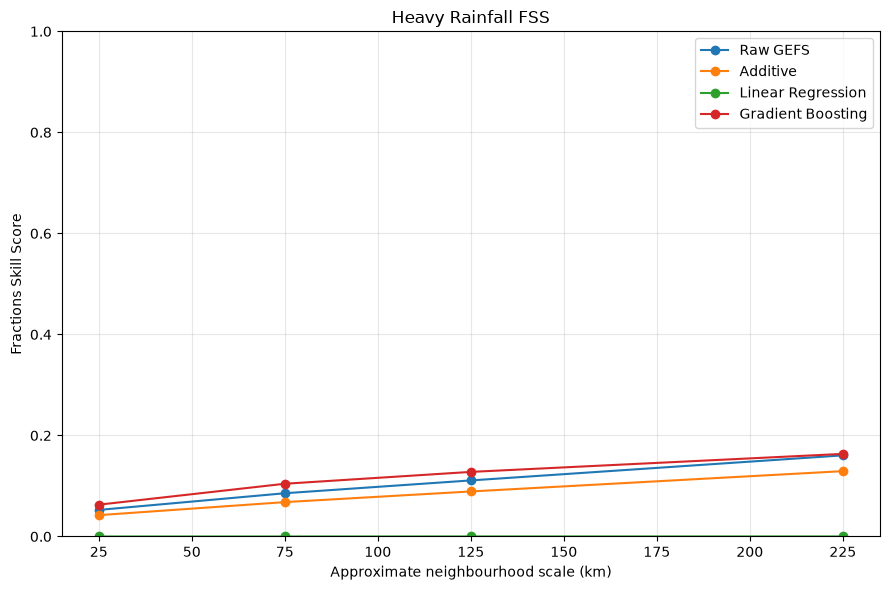

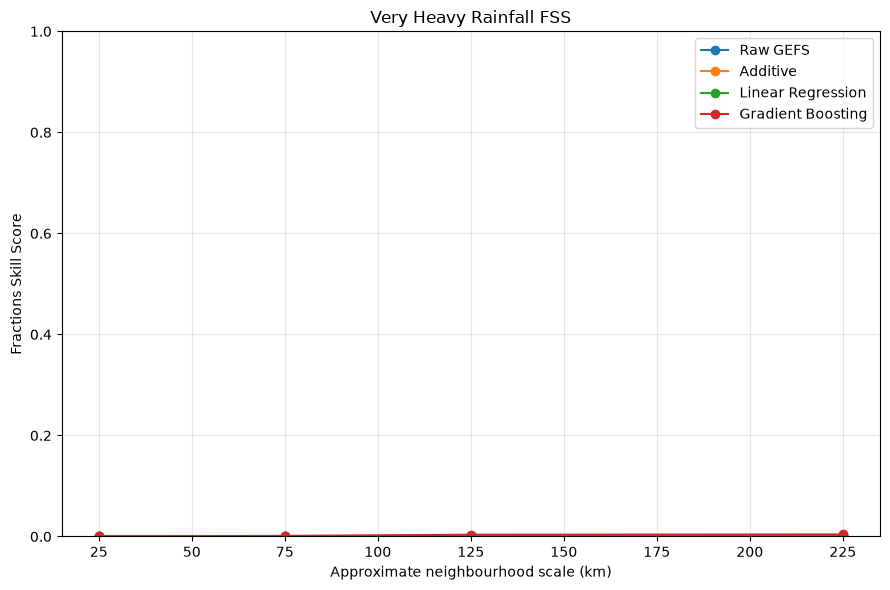

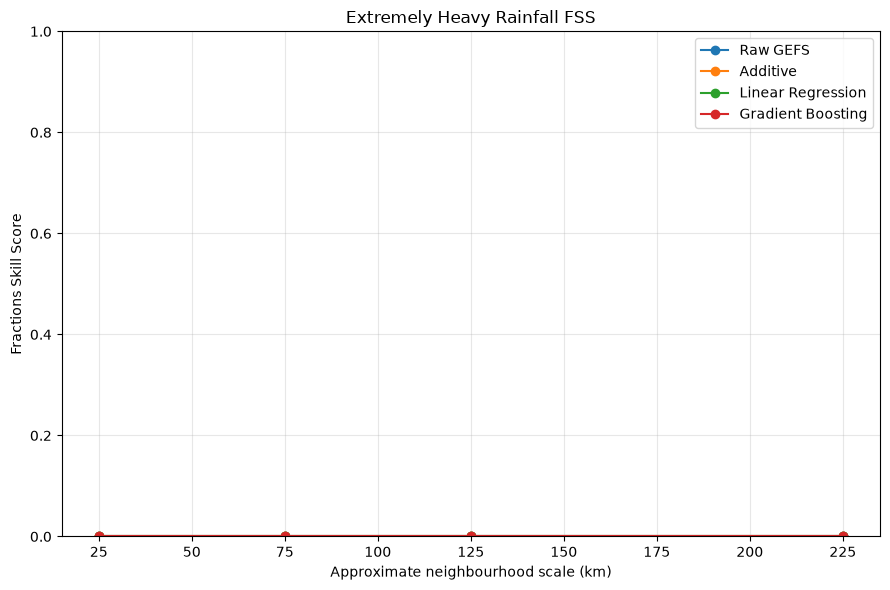

In [8]:
for category in THRESHOLDS:
    category_data = fss_df[
        fss_df["category"] == category
    ]

    plt.figure(figsize=(9, 6))

    for model_name in MODEL_VARIABLES:
        model_data = category_data[
            category_data["model"] == model_name
        ]

        plt.plot(
            model_data["approximate_scale_km"],
            model_data["FSS"],
            marker="o",
            label=model_name
        )

    plt.xlabel("Approximate neighbourhood scale (km)")
    plt.ylabel("Fractions Skill Score")
    plt.title(f"{category} Rainfall FSS")
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [9]:
categorical_output = categorical_df.copy()
categorical_output["metric_type"] = "categorical"

fss_output = fss_df.copy()
fss_output["metric_type"] = "FSS"

extreme_metrics = pd.concat(
    [
        categorical_output,
        fss_output
    ],
    ignore_index=True,
    sort=False
)

extreme_metrics.to_csv(
    OUTPUT_FILE,
    index=False
)

print("Saved:", OUTPUT_FILE.exists())
print("Location:", OUTPUT_FILE)

Saved: True
Location: Z:\Projects\monsoon-postprocessing\data\processed\july2018_extreme_metrics.csv


In [10]:
display(selected_comparison)

,model,category,hits,misses,false_alarms,CSI,POD,FAR,ETS
0,Raw GEFS,Heavy,64,1064,1241,0.027016,0.056738,0.950958,0.018948
1,Raw GEFS,Very Heavy,0,145,161,0.000000,0.000000,1.000000,-0.001011
2,Raw GEFS,Extremely Heavy,0,11,3,0.000000,0.000000,1.000000,-0.000031
6,Linear Regression,Heavy,0,1128,5,0.000000,0.000000,1.000000,-0.000066
7,Linear Regression,Very Heavy,0,145,0,0.000000,0.000000,NaN,0.000000
8,Linear Regression,Extremely Heavy,0,11,0,0.000000,0.000000,NaN,0.000000
